# Symbulate Graphics Gallery

A single reference for Symbulate's plotting: every 1D and 2D plot type with its
default and alternatives, the overlay mechanism, marginal plots, jitter modes,
and the theoretical-distribution features (`cdf=True`, `xlim="zoom"`, `shade()`).

Each plot of *simulated data* has a **default** type chosen from the data, plus
**alternatives** you select with `type=`. When you call `.plot()` without a type,
a message names the default and lists the alternatives — that is what documents
the choices below. (Pass `suggest=False` to silence it, `suggest=True` to force it.)

In [37]:
from symbulate import *

---
## 1D plot types

### Discrete data, large n — default: **impulse**
The message below names the default and the alternatives (`type='hist'`, etc.).

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


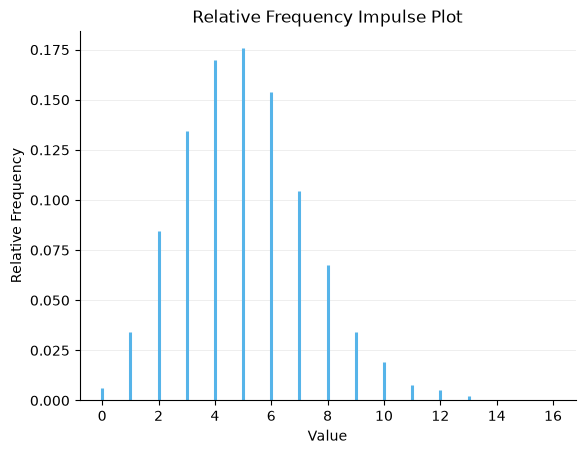

In [38]:
RV(Poisson(5)).sim(10000).plot(suggest=True)

Alternatives — histogram and ECDF:

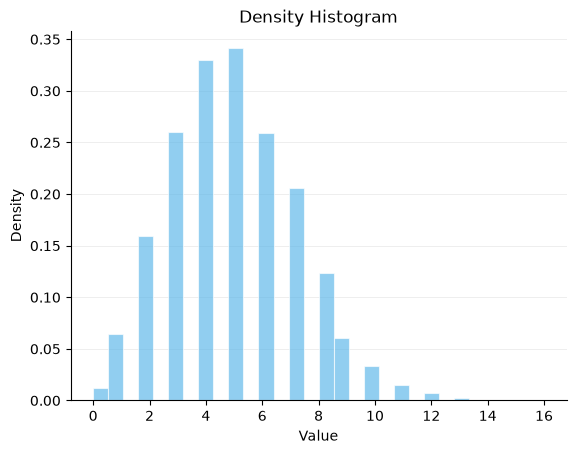

In [39]:
RV(Poisson(5)).sim(10000).plot(type='hist')

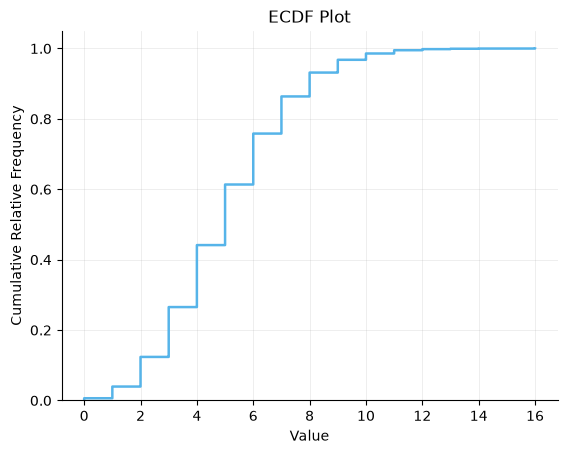

In [40]:
RV(Poisson(5)).sim(10000).plot(type='ecdf', suggest=False)

### Discrete data, small n — default: **dot plot**

Currently Showing: Dot Plot (Default)
Alternative Plots: Impulse Plot (type = "impulse"), Histogram (type = "hist"), ECDF Plot (type = "ecdf")


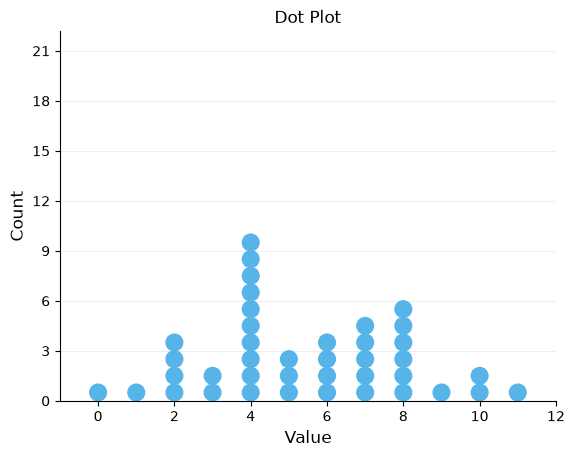

In [41]:
RV(Poisson(5)).sim(40).plot(suggest=True)

### Continuous data, large n — default: **histogram**

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


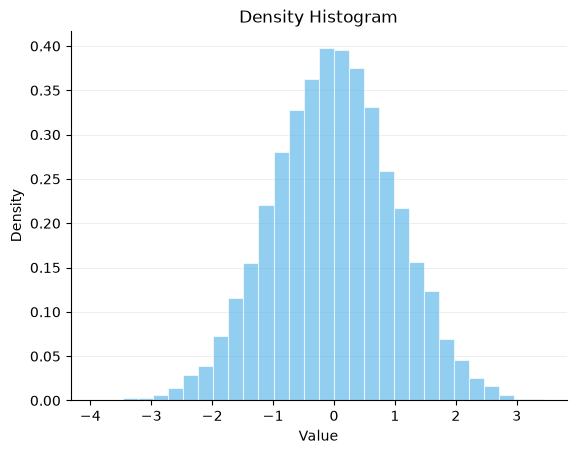

In [42]:
RV(Normal(0, 1)).sim(10000).plot(suggest=True)

Alternatives — density, box, and violin:

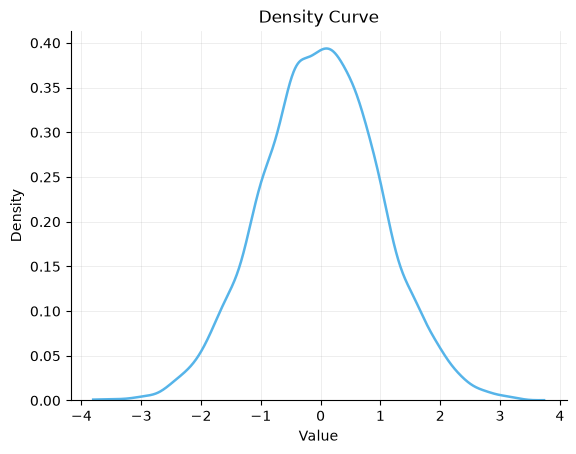

In [43]:
RV(Normal(0, 1)).sim(10000).plot(type='density', suggest=False)

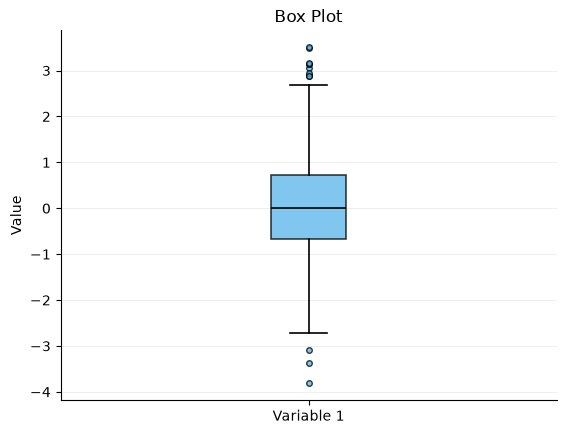

In [44]:
RV(Normal(0, 1)).sim(2000).plot(type='box', suggest=False)

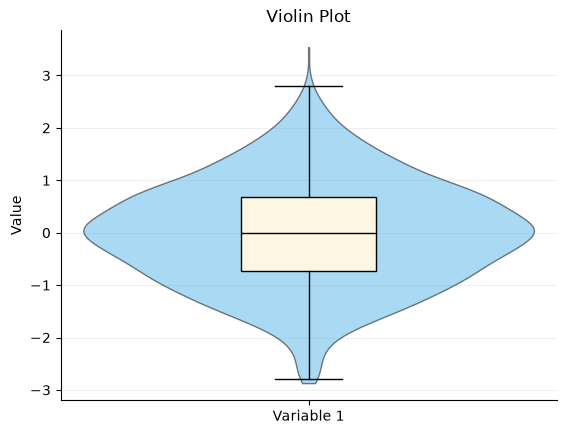

In [45]:
RV(Normal(0, 1)).sim(2000).plot(type='violin', suggest=False)

### Continuous data, small n — default: **rug plot**

Currently Showing: Rug Plot (Default)
Alternative Plots: Histogram (type = "hist"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


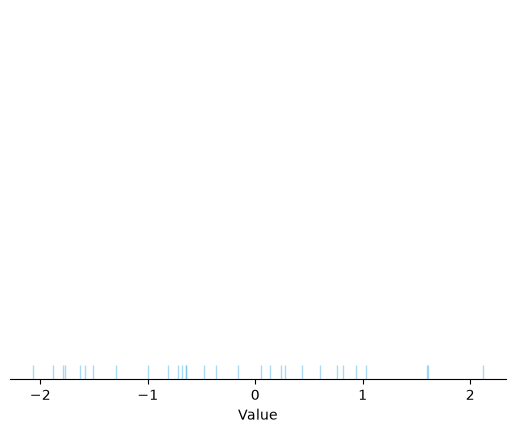

In [46]:
RV(Normal(0, 1)).sim(30).plot(suggest=True)

### Categorical data — default: **bar** (large n) / **dot plot** (small n)

Currently Showing: Bar Chart (Default)
Alternative Plots: Dot Plot (type = "dotplot"), Impulse Plot (type = "impulse")


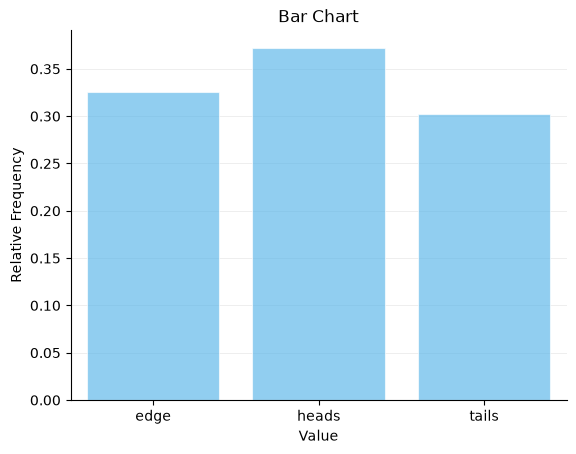

In [47]:
RV(BoxModel(['heads', 'tails', 'edge'])).sim(500).plot(suggest=True)

---
## 2D plot types

### Discrete × discrete — **scatter** (small n), **tile** (large n), **mosaic**

Currently Showing: Scatter Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Mosaic Plot (type = "mosaic")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


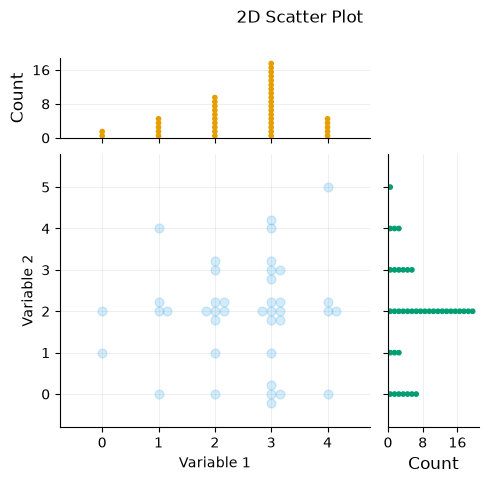

In [48]:
RV(Binomial(5, 0.4) ** 2).sim(40).plot(suggest=True)

Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic")


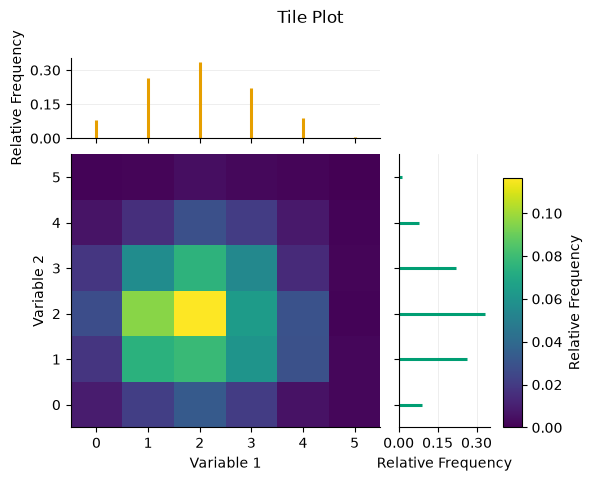

In [49]:
RV(Binomial(5, 0.4) ** 2).sim(2000).plot(suggest=True)

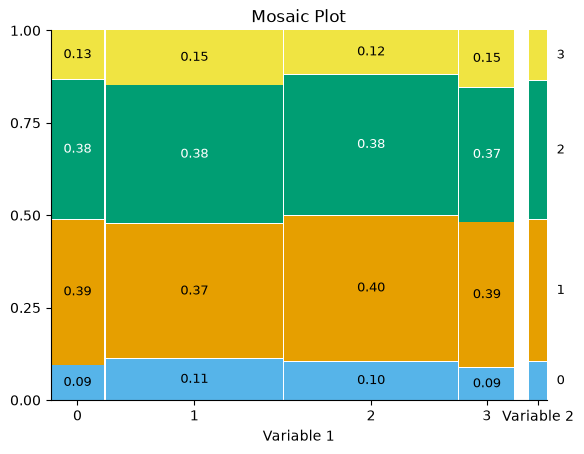

In [50]:
RV(Binomial(3, 0.5) ** 2).sim(2000).plot(type='mosaic', suggest=False)

The **stacked bar chart** is the mosaic with `equal_width=True`: every column is the same width (titled "Stacked Plot"), so the segments show each x-value's conditional distribution as a 100%-stacked bar rather than scaling column width by frequency.

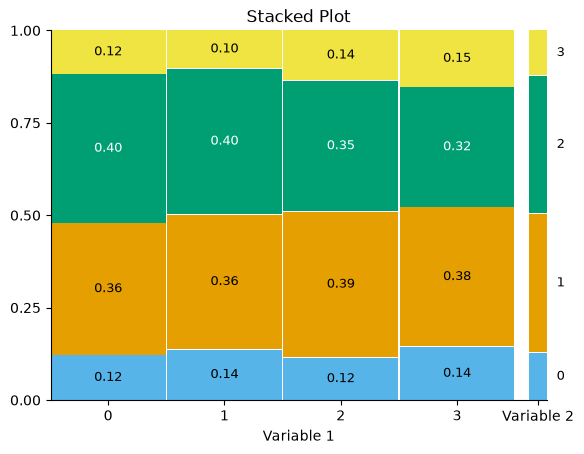

In [51]:
RV(Binomial(3, 0.5) ** 2).sim(2000).plot(type='mosaic', equal_width=True, suggest=False)

### Continuous × continuous — **scatter** (small n), **2D histogram** (large n), **2D density**

Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


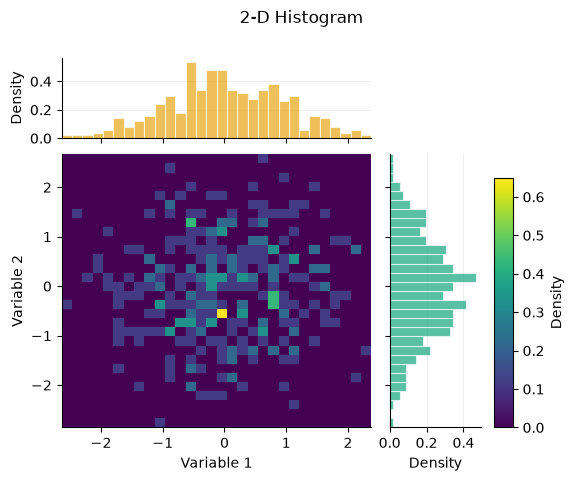

In [52]:
RV(Normal(0, 1) ** 2).sim(300).plot(suggest=True)

Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


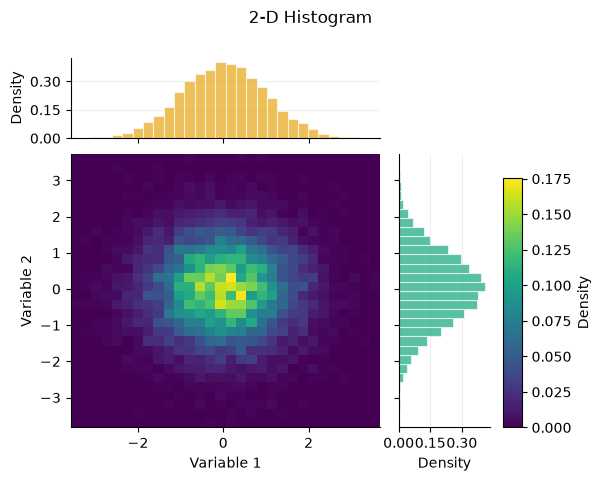

In [53]:
RV(Normal(0, 1) ** 2).sim(10000).plot(suggest=True)

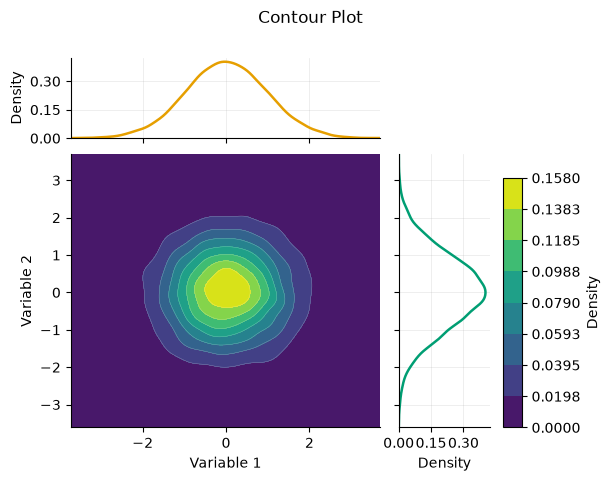

In [54]:
RV(Normal(0, 1) ** 2).sim(10000).plot(type='density2d', suggest=False)

### Mixed discrete × continuous — **segmented** plots (small n), **box/violin/tile** (large n)
The short names `rug`/`density`/`hist` resolve to their segmented forms on mixed data.

Currently Showing: Rug Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Box Plot (type = "box"), Violin Plot (type = "violin"), Density Plot (type = "density"), Histogram (type = "hist")


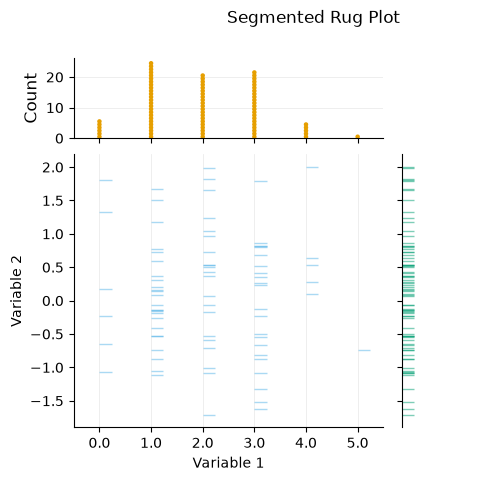

In [55]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(80).plot(suggest=True)

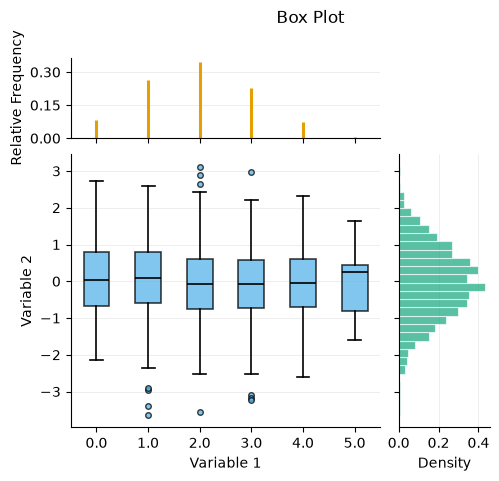

In [56]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type='box', suggest=False)

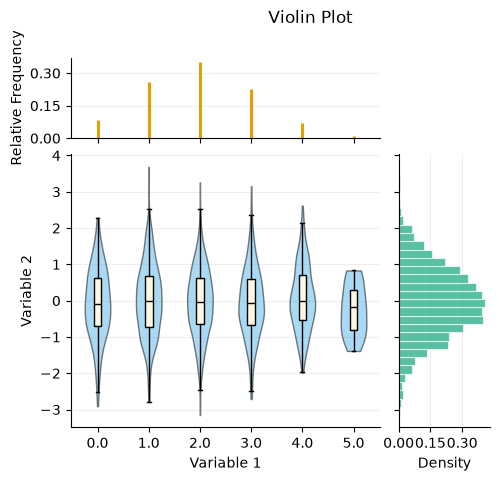

In [57]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type='violin', suggest=False)

---
## Overlay: simulated + theoretical
Two `.plot()` calls in one cell draw on the same axes. A simulated histogram with
its theoretical pmf overlaid:

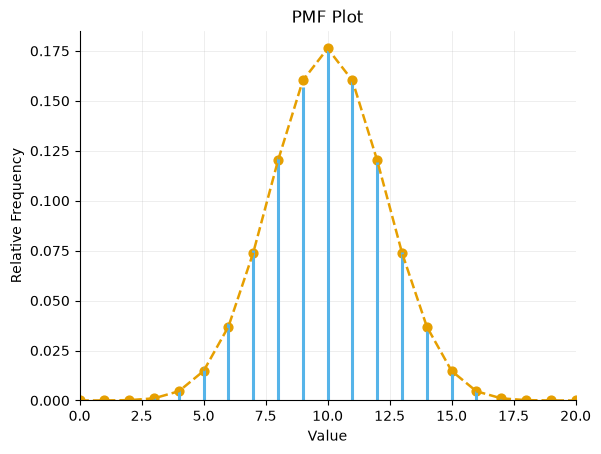

In [58]:
RV(Binomial(20, 0.5)).sim(10000).plot(suggest=False)
Binomial(20, 0.5).plot()

### Multiple series
Different batches of data get distinct colors automatically.

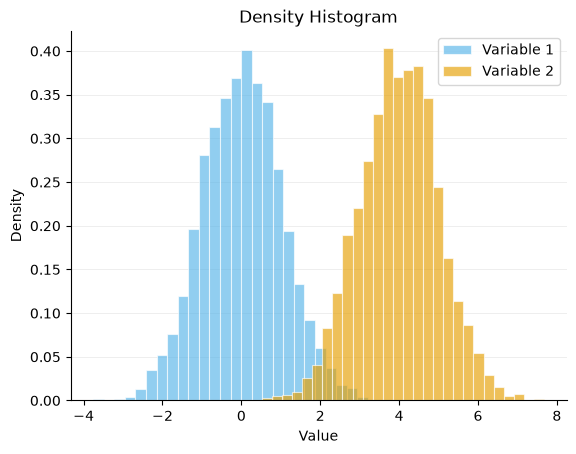

In [59]:
RV(Normal(0, 1)).sim(5000).plot(suggest=False)
RV(Normal(4, 1)).sim(5000).plot(suggest=False)

---
## Marginal plots
Add `marginal=True` to a 2D plot for aligned marginal panels on each axis.

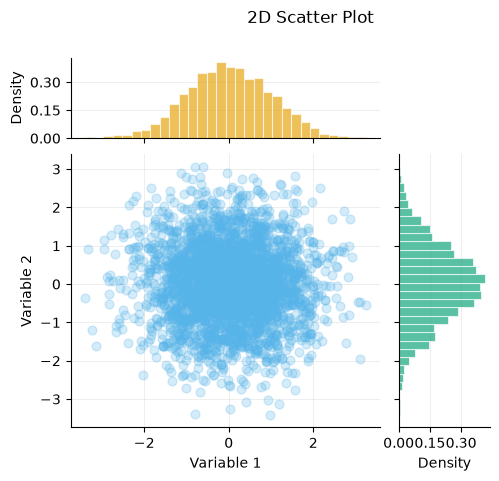

In [60]:
RV(Normal(0, 1) ** 2).sim(3000).plot(type='scatter', suggest=False)

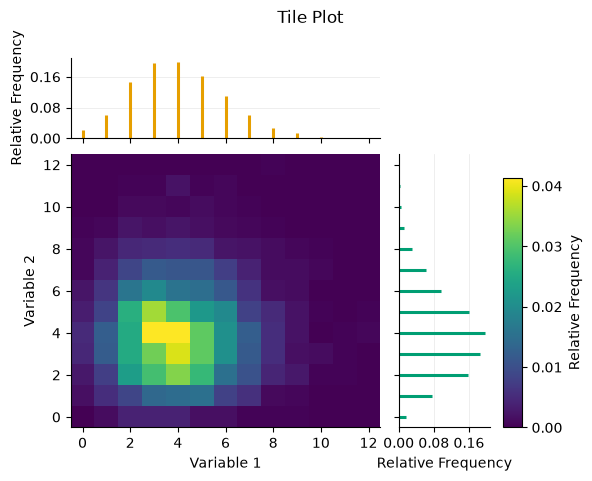

In [61]:
RV(Poisson(4) ** 2).sim(3000).plot(type='tile', suggest=False)

---
## Jitter modes (discrete 2D scatter)
When many points share a value, `jitter=` controls how they spread apart. The note
under the plot lists the options.

Currently Showing: Scatter Plot
Alternative Plots: Tile Plot (Default), Mosaic Plot (type = "mosaic")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


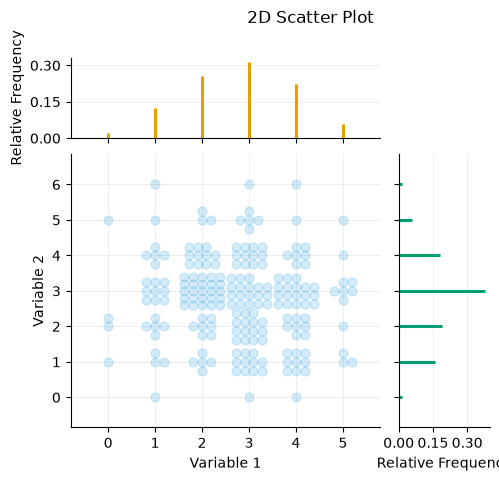

In [62]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='spiral', suggest=True)

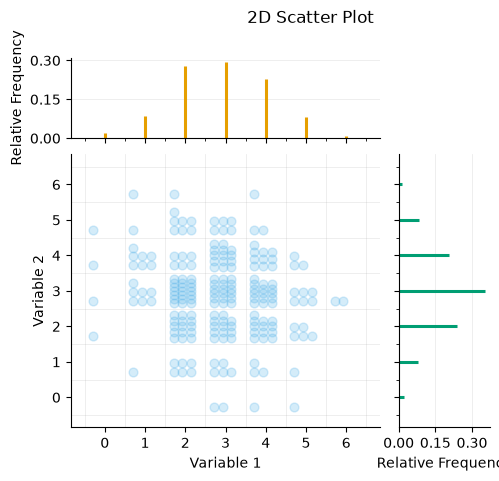

In [63]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='bins', suggest=False)

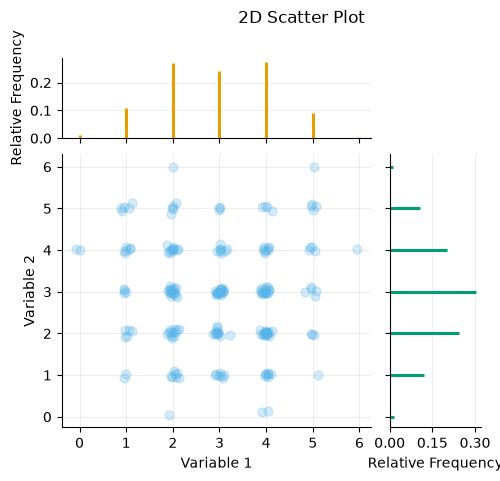

In [64]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='random', suggest=False)

---
## Theoretical distribution plots

### pmf / pdf and CDF
A distribution's `.plot()` draws the pmf/pdf; `cdf=True` draws the CDF.

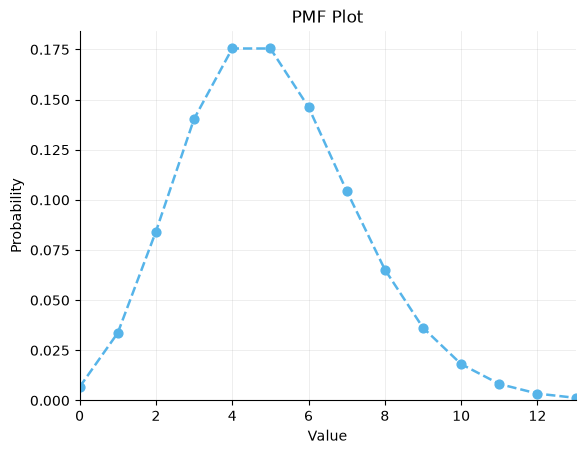

In [65]:
Poisson(5).plot()

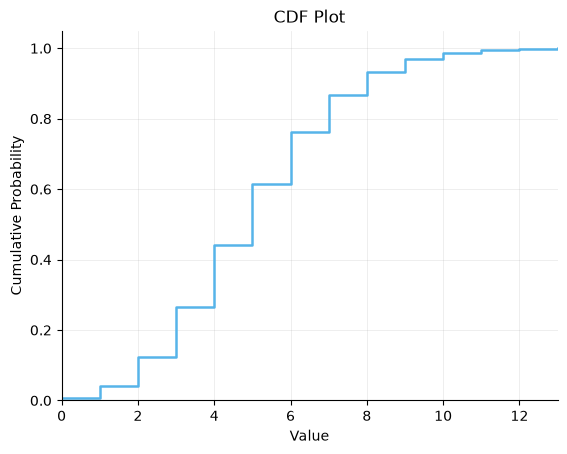

In [66]:
Poisson(5).plot(cdf=True)

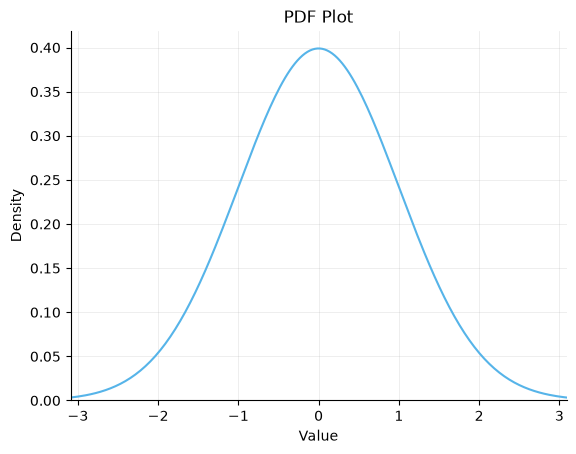

In [67]:
Normal(0, 1).plot()

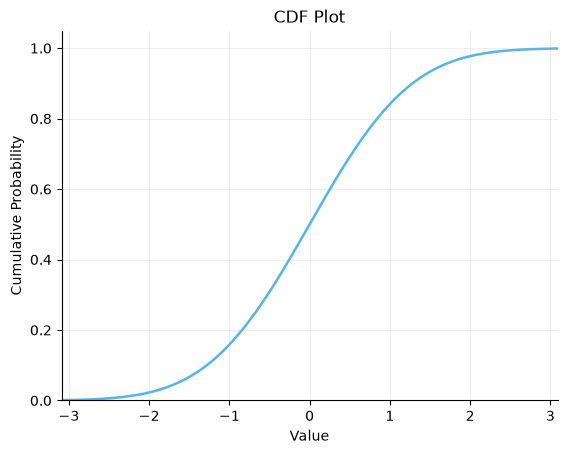

In [68]:
Normal(0, 1).plot(cdf=True)

### Tight window with `xlim="zoom"`
Frames a theoretical curve on the high-probability region instead of the full
support — useful when overlaying on simulated data, which occupies only part of it.

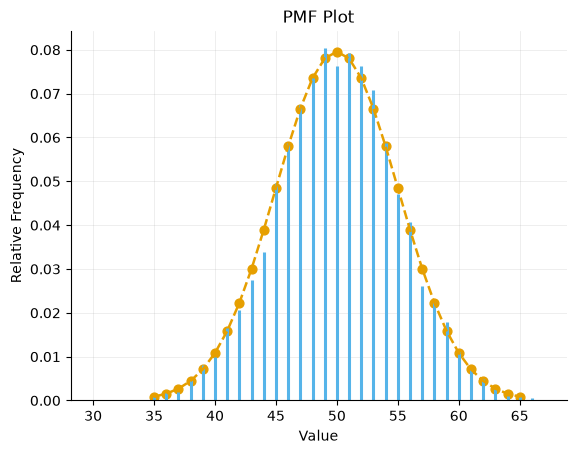

In [69]:
RV(Binomial(100, 0.5)).sim(10000).plot(suggest=False)
Binomial(100, 0.5).plot(xlim='zoom')

### Shading regions with `shade()`
Chain `.shade()` off a distribution's `.plot()` to fill a tail or interval.
`lt`/`le` set an upper bound, `gt`/`ge` a lower bound.

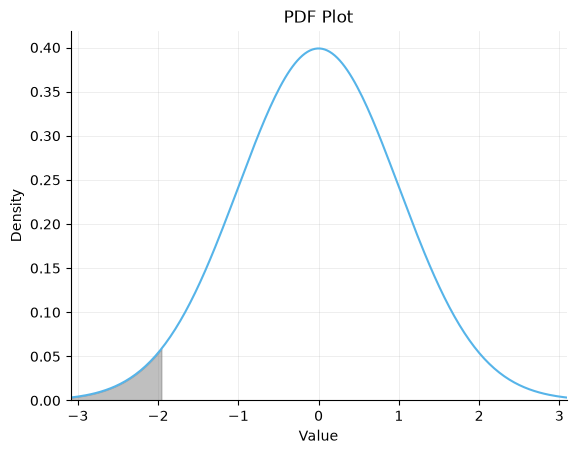

In [70]:
Normal(0, 1).plot().shade(lt=-1.96)

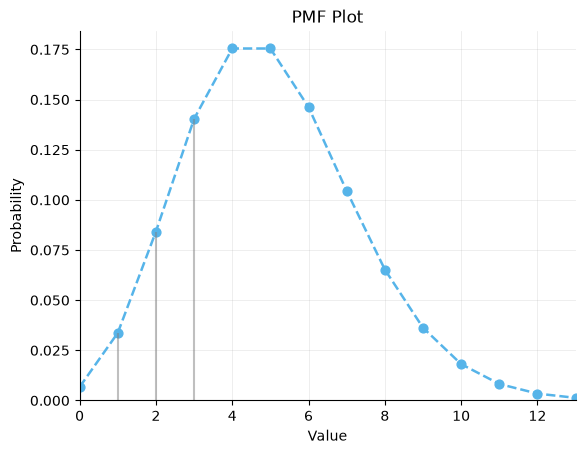

In [71]:
Poisson(5).plot().shade(le=3)

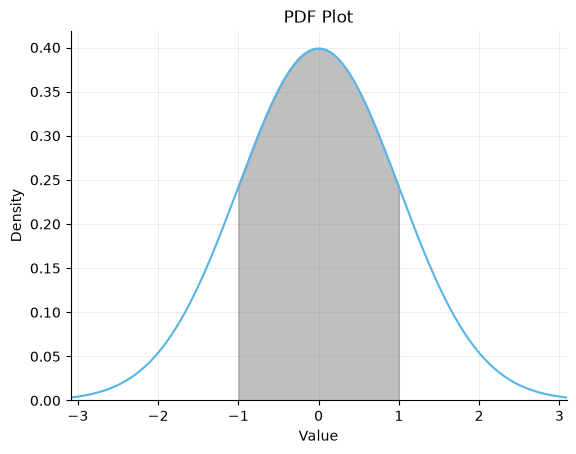

In [72]:
Normal(0, 1).plot().shade(gt=-1, lt=1)